In [7]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import cv2
import glob
from adjustText import adjust_text
import matplotlib.gridspec as gridspec

import libs.utils as util
import libs.plotting as putil
import transform_data.relative_metrics as rel
from analyses.preprocessing.src.add_ft_actions import add_ft_actions

In [ ]:
# Set plot params
# -------------------------------------------------------------------
plot_style = 'dark'
min_fontsize = 12
putil.set_sns_style(style=plot_style, min_fontsize=min_fontsize)
bg_color = [0.7]*3 if plot_style == 'dark' else 'k'


In [3]:
# Paths
# -------------------------------------------------------------------
rootdir = '/Volumes/Julie/20260427_free_behavior/' # root directory containing experiment data
acquisition_parentdir = os.path.join(rootdir, 'raw_videos')
# Get list of acquisitions (no hidden)
acqs = [f for f in os.listdir(acquisition_parentdir) if not f.startswith('.')]
print(f"Found {len(acqs)} acquisitions")

# Processed data directory
processedmat_dir = os.path.join(rootdir, 'processed_mats')
if not os.path.exists(processedmat_dir):
    os.makedirs(processedmat_dir)

# Figure directory
figdir = os.path.join(rootdir, 'figures')
os.makedirs(figdir, exist_ok=True)
print(f"Saving figures to {figdir}")

Found 19 acquisitions
Saving figures to /Volumes/Julie/20260427_free_behavior/figures


In [4]:
# Load FlyTracker data 
# -----------------------------------------
acq = acqs[0]
acq_dir = os.path.join(acquisition_parentdir, acq)
calib, trk, feat = util.load_flytracker_data(acq_dir, 
                        calib_is_upstream=False, filter_ori=True)
n_frames = len(trk[trk['id']==0])
n_flies = trk['id'].nunique()
trk['frame'] = list(range(n_frames)) * n_flies
print(f"Loaded data for {acq}")
print(calib)

# Save directory for this acquisition
# -------------------------------------------------------------------
save_dir = os.path.join(figdir, acq)
os.makedirs(save_dir, exist_ok=True)

DEBUG load_calibration parsed: {'n_chambers': (1, 'int', ''), 'n_rows': (1, 'int', ''), 'n_cols': (1, 'int', ''), 'FPS': (60, 'int', ''), 'PPM': (21.76848786002168, 'float', ''), 'centroids': (array([462.4, 441.9]), 'ndarray', (2,)), 'w': (830.8000000000001, 'float', ''), 'h': (829.4, 'float', ''), 'rois': (array([ 28,  48, 829, 830], dtype=uint16), 'ndarray', (4,)), 'n_flies': (3, 'int', '')}
Loaded data for 20260430-1021_MMF-triad3_Dmel_CantonS_4M-5Fdo_gh
{'n_chambers': 1, 'n_rows': 1, 'n_cols': 1, 'FPS': 60, 'PPM': 21.76848786002168, 'centroids': array([462.4, 441.9]), 'w': 830.8000000000001, 'h': 829.4, 'rois': array([ 28,  48, 829, 830], dtype=uint16), 'n_flies': 3}


Saved to /Volumes/Julie/20260427_free_behavior/figures/20260430-1021_MMF-triad3_Dmel_CantonS_4M-5Fdo_gh/first_frame_sanity_check.png


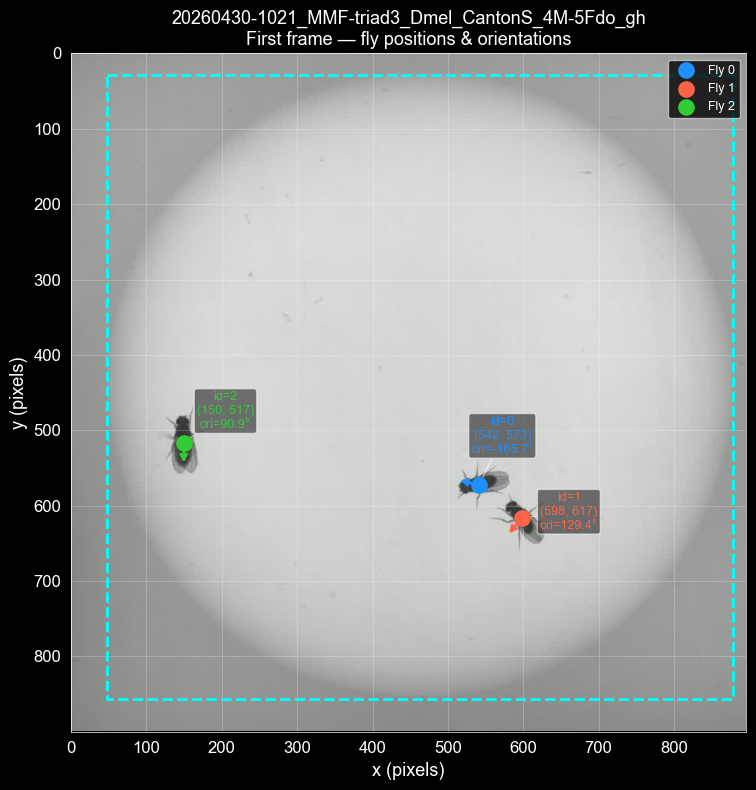

In [5]:
# Grab first frame from .avi
# -------------------------------------------------------------------
avi_files = glob.glob(os.path.join(acq_dir, '*.avi'))
assert len(avi_files) > 0, f"No .avi found in {acq_dir}"
avi_path = avi_files[0]

cap = cv2.VideoCapture(avi_path)
ret, frame = cap.read()
cap.release()
assert ret, "Failed to read first frame"
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

# Get first-frame fly data and ROI
# -------------------------------------------------------------------
frame_height, frame_width = frame_rgb.shape[:2]

# ROI: [x_start, y_start, width, height]
roi = calib['rois']  # [y0, x0, roi_h, roi_w]
y0, x0, roi_h, roi_w = roi

# First frame per fly
trk0 = trk.groupby('id').first().reset_index()

# Plot
# -------------------------------------------------------------------
# Colors per fly id
id_colors = {0: 'dodgerblue', 1: 'tomato', 2: 'limegreen'}

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(frame_rgb, origin='upper')

# ROI bounding box
rect = plt.Rectangle((x0, y0), roi_w, roi_h,
                      linewidth=2, edgecolor='cyan', facecolor='none', linestyle='--')
ax.add_patch(rect)

texts = []
for i, row in trk0.iterrows():
    fly_id = int(row['id'])
    px, py = row['pos_x'], row['pos_y']
    ori = row['ori']
    color = id_colors.get(fly_id, 'white')

    ax.scatter(px, py, s=120, color=color, zorder=5, label=f'Fly {fly_id}')

    arrow_len = 30
    dx = arrow_len * np.cos(ori)
    dy = arrow_len * np.sin(ori)
    ax.annotate('', xy=(px + dx, py + dy), xytext=(px, py),
                arrowprops=dict(arrowstyle='->', color=color, lw=2))

    t = ax.text(px, py,
                f"id={fly_id}\n({px:.0f}, {py:.0f})\nori={np.rad2deg(ori):.1f}°",
                color=color, fontsize=9,
                bbox=dict(boxstyle='round,pad=0.2', fc='black', alpha=0.5))
    texts.append(t)

adjust_text(texts, ax=ax,
            expand=(1.5, 1.5),
            arrowprops=dict(arrowstyle='-', color='white', lw=0.8, alpha=0.6))

ax.set_xlim(0, frame_width)
ax.set_ylim(frame_height, 0)
ax.set_xlabel('x (pixels)')
ax.set_ylabel('y (pixels)')
ax.set_title(f'{acq}\nFirst frame — fly positions & orientations')
ax.legend(loc='upper right', fontsize=9)

ax.set_xticks(np.arange(0, frame_width, 100))
ax.set_yticks(np.arange(0, frame_height, 100))
ax.grid(True, color='white', linewidth=0.5, alpha=0.3)

plt.tight_layout()
savepath = os.path.join(save_dir, 'first_frame_sanity_check.png')
fig.savefig(savepath, dpi=150)
print(f"Saved to {savepath}")
plt.show()

In [6]:
# Process and transform
# -----------------------------------------
centroid_x = calib['centroids'][0]
centroid_y = calib['centroids'][1]
cop_ix = None
fps = calib['FPS']

trk['ori'] = -1*trk['ori'] # flip for FT to match DLC and plot with 0, 0 at bottom left
df = rel.do_transformations_on_df(trk, centroid_x, centroid_y, 
                                feat_=feat, cop_ix=None,
                                flyid1=0, flyid2=1, 
                                get_relative_sizes=False)

In [ ]:
# Pick a random frame
# -------------------------------------------------------------------
rng = np.random.default_rng(42)
frame_idx = int(rng.integers(0, df['frame'].max()))
print(f"Using frame {frame_idx}")

# Grab that frame from video
cap = cv2.VideoCapture(avi_path)
cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
ret, frame = cap.read()
cap.release()
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
frame_h, frame_w = frame_rgb.shape[:2]

# Get fly data for this frame
f0 = df[(df['id']==0) & (df['frame']==frame_idx)].iloc[0]
f1 = df[(df['id']==1) & (df['frame']==frame_idx)].iloc[0]

print("\n--- Absolute positions (pixel space) ---")
for label, f in [('Fly 0', f0), ('Fly 1', f1)]:
    print(f"{label}: pos=({f['pos_x']:.1f}, {f['pos_y']:.1f})  "
          f"ori={np.rad2deg(f['ori']):.1f}°  "
          f"ctr=({f['ctr_x']:.1f}, {f['ctr_y']:.1f})")

Using frame 9639

--- Absolute positions (pixel space) ---
Fly 0: pos=(458.4, 781.0)  ori=-145.3°  ctr=(-4.0, 339.1)
Fly 1: pos=(379.6, 770.6)  ori=-160.2°  ctr=(-82.8, 328.7)


/var/folders/yn/hhhbphln52q4k8kj83hd0c3m0000gn/T/ipykernel_21353/246128735.py:183: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved to /Volumes/Julie/20260427_free_behavior/figures/20260430-1021_MMF-triad3_Dmel_CantonS_4M-5Fdo_gh/yaxis_diagnostic_frame9639.png


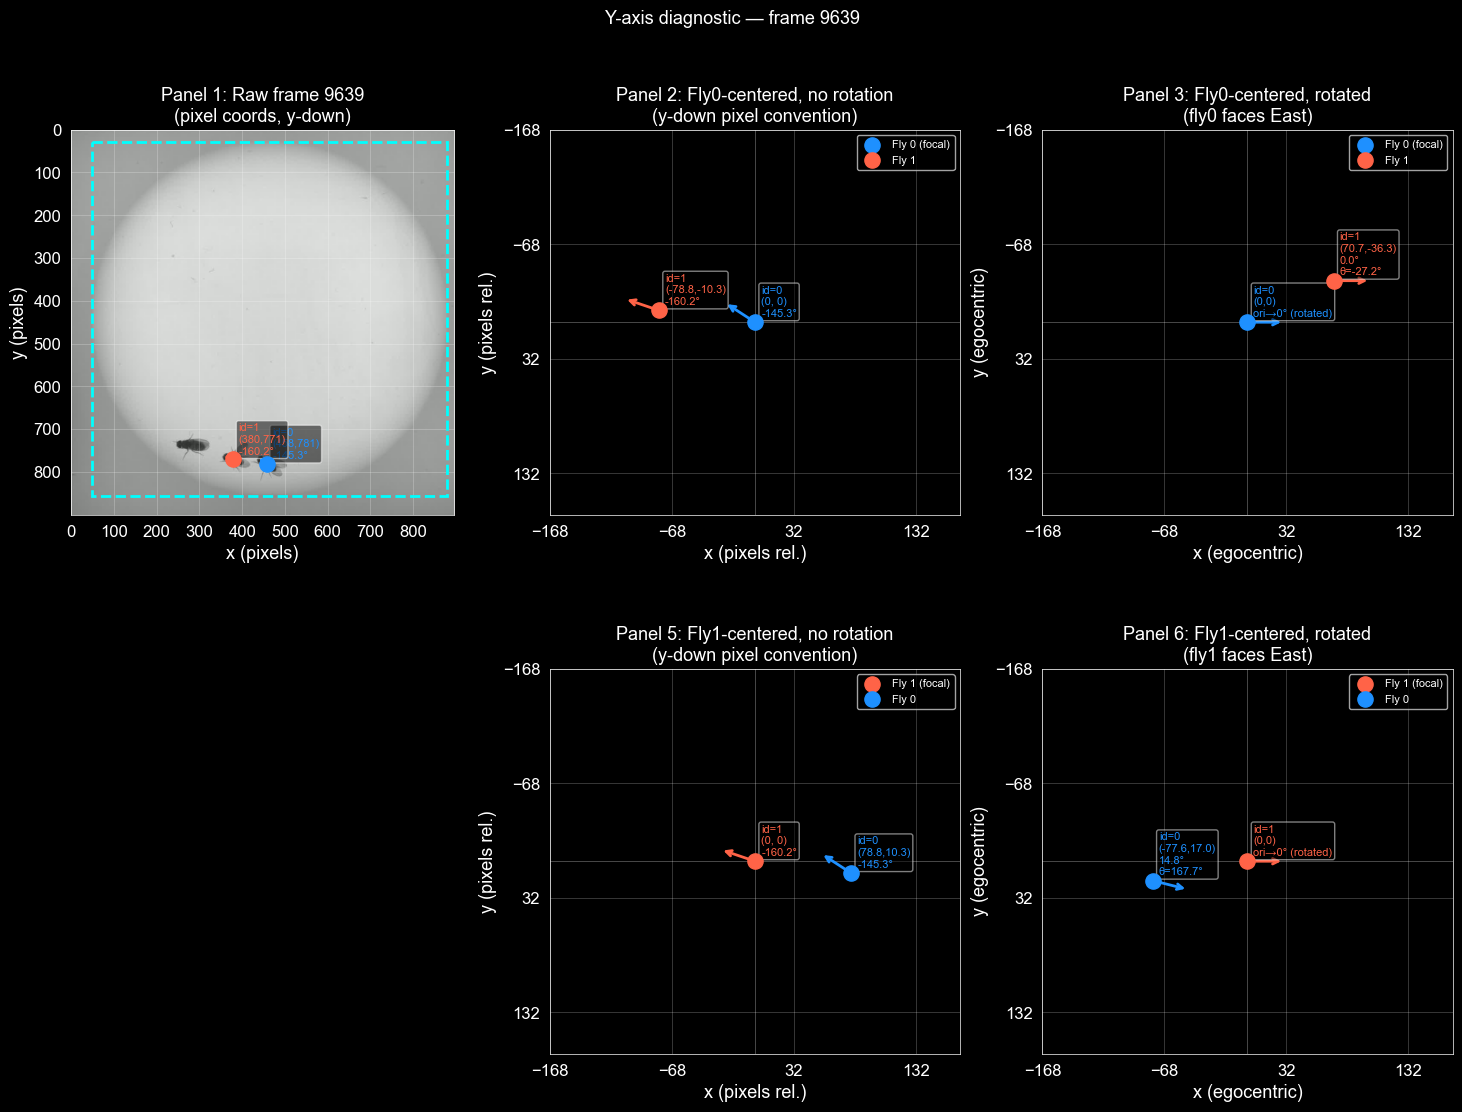

In [11]:
fig = plt.figure(figsize=(18, 12))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4)

id_colors = {0: 'dodgerblue', 1: 'tomato'}

# ---- Panel 1: Raw video frame ----
ax1 = fig.add_subplot(gs[0, 0])
ax1.imshow(frame_rgb, origin='upper')

roi = calib['rois']
y0_roi, x0_roi, roi_h, roi_w = roi
rect = plt.Rectangle((x0_roi, y0_roi), roi_w, roi_h,
                      lw=2, edgecolor='cyan', facecolor='none', ls='--')
ax1.add_patch(rect)

for fly_id, f in [(0, f0), (1, f1)]:
    color = id_colors[fly_id]
    px, py = f['pos_x'], f['pos_y']
    ori = f['ori']
    ax1.scatter(px, py, s=120, color=color, zorder=5)
    arrow_len = 30
    ax1.annotate('', xy=(px + arrow_len*np.cos(ori), py + arrow_len*np.sin(ori)),
                xytext=(px, py),
                arrowprops=dict(arrowstyle='->', color=color, lw=2))
    ax1.text(px+12, py-12, f"id={fly_id}\n({px:.0f},{py:.0f})\n{np.rad2deg(ori):.1f}°",
             color=color, fontsize=8,
             bbox=dict(boxstyle='round,pad=0.2', fc='black', alpha=0.5))

ax1.set_xlim(0, frame_w)
ax1.set_ylim(frame_h, 0)
ax1.set_xticks(np.arange(0, frame_w, 100))
ax1.set_yticks(np.arange(0, frame_h, 100))
ax1.grid(True, color='white', lw=0.5, alpha=0.3)
ax1.set_title(f'Panel 1: Raw frame {frame_idx}\n(pixel coords, y-down)')
ax1.set_xlabel('x (pixels)'); ax1.set_ylabel('y (pixels)')

# ---- Panel 2: Fly0-centered, no rotation ----
ax2 = fig.add_subplot(gs[0, 1])

rel_x = f0['targ_centered_to_focal_x']
rel_y = f0['targ_centered_to_focal_y']

ax2.scatter(0, 0, s=120, color=id_colors[0], zorder=5, label='Fly 0 (focal)')
arrow_len = 30
ori0 = f0['ori']
ax2.annotate('', xy=(arrow_len*np.cos(ori0), arrow_len*np.sin(ori0)),
             xytext=(0, 0),
             arrowprops=dict(arrowstyle='->', color=id_colors[0], lw=2))
ax2.text(5, -5, f"id=0\n(0, 0)\n{np.rad2deg(ori0):.1f}°",
         color=id_colors[0], fontsize=8,
         bbox=dict(boxstyle='round,pad=0.2', fc='black', alpha=0.5))

ax2.scatter(rel_x, rel_y, s=120, color=id_colors[1], zorder=5, label='Fly 1')
ax2.annotate('', xy=(rel_x + arrow_len*np.cos(f1['ori']), rel_y + arrow_len*np.sin(f1['ori'])),
             xytext=(rel_x, rel_y),
             arrowprops=dict(arrowstyle='->', color=id_colors[1], lw=2))
ax2.text(rel_x+5, rel_y-5, f"id=1\n({rel_x:.1f},{rel_y:.1f})\n{np.rad2deg(f1['ori']):.1f}°",
         color=id_colors[1], fontsize=8,
         bbox=dict(boxstyle='round,pad=0.2', fc='black', alpha=0.5))

ax2.axhline(0, color='white', lw=0.5, alpha=0.4)
ax2.axvline(0, color='white', lw=0.5, alpha=0.4)
lim = max(abs(rel_x), abs(rel_y)) * 1.5 + 50
ax2.set_xlim(-lim, lim)
ax2.set_ylim(lim, -lim)
ax2.set_xticks(np.arange(-int(lim), int(lim), 100))
ax2.set_yticks(np.arange(-int(lim), int(lim), 100))
ax2.grid(True, color='white', lw=0.5, alpha=0.3)
ax2.set_title('Panel 2: Fly0-centered, no rotation\n(y-down pixel convention)')
ax2.set_xlabel('x (pixels rel.)'); ax2.set_ylabel('y (pixels rel.)')
ax2.legend(fontsize=8)

# ---- Panel 3: Fly0-centered, after rotation ----
ax3 = fig.add_subplot(gs[0, 2])

rot_x = f0['targ_rel_pos_x']
rot_y = f0['targ_rel_pos_y']
rot_ori1 = f1['rot_ori']

ax3.scatter(0, 0, s=120, color=id_colors[0], zorder=5, label='Fly 0 (focal)')
ax3.annotate('', xy=(arrow_len, 0), xytext=(0, 0),
             arrowprops=dict(arrowstyle='->', color=id_colors[0], lw=2))
ax3.text(5, -5, f"id=0\n(0,0)\nori→0° (rotated)",
         color=id_colors[0], fontsize=8,
         bbox=dict(boxstyle='round,pad=0.2', fc='black', alpha=0.5))

ax3.scatter(rot_x, rot_y, s=120, color=id_colors[1], zorder=5, label='Fly 1')
ax3.annotate('', xy=(rot_x + arrow_len*np.cos(rot_ori1), rot_y + arrow_len*np.sin(rot_ori1)),
             xytext=(rot_x, rot_y),
             arrowprops=dict(arrowstyle='->', color=id_colors[1], lw=2))
ax3.text(rot_x+5, rot_y-5,
         f"id=1\n({rot_x:.1f},{rot_y:.1f})\n{np.rad2deg(rot_ori1):.1f}°\nθ={np.rad2deg(f0['targ_pos_theta']):.1f}°",
         color=id_colors[1], fontsize=8,
         bbox=dict(boxstyle='round,pad=0.2', fc='black', alpha=0.5))

ax3.axhline(0, color='white', lw=0.5, alpha=0.4)
ax3.axvline(0, color='white', lw=0.5, alpha=0.4)
ax3.set_xlim(-lim, lim)
ax3.set_ylim(lim, -lim)
ax3.set_xticks(np.arange(-int(lim), int(lim), 100))
ax3.set_yticks(np.arange(-int(lim), int(lim), 100))
ax3.grid(True, color='white', lw=0.5, alpha=0.3)
ax3.set_title('Panel 3: Fly0-centered, rotated\n(fly0 faces East)')
ax3.set_xlabel('x (egocentric)'); ax3.set_ylabel('y (egocentric)')
ax3.legend(fontsize=8)

# ---- Panel 4: placeholder to keep grid aligned ----
ax4 = fig.add_subplot(gs[1, 0])
ax4.axis('off')

# ---- Panel 5: Fly1-centered, no rotation ----
ax5 = fig.add_subplot(gs[1, 1])

# from fly1's perspective, fly0's relative position
rel_x_1 = f1['targ_centered_to_focal_x']
rel_y_1 = f1['targ_centered_to_focal_y']
ori1 = f1['ori']

ax5.scatter(0, 0, s=120, color=id_colors[1], zorder=5, label='Fly 1 (focal)')
ax5.annotate('', xy=(arrow_len*np.cos(ori1), arrow_len*np.sin(ori1)),
             xytext=(0, 0),
             arrowprops=dict(arrowstyle='->', color=id_colors[1], lw=2))
ax5.text(5, -5, f"id=1\n(0, 0)\n{np.rad2deg(ori1):.1f}°",
         color=id_colors[1], fontsize=8,
         bbox=dict(boxstyle='round,pad=0.2', fc='black', alpha=0.5))

ax5.scatter(rel_x_1, rel_y_1, s=120, color=id_colors[0], zorder=5, label='Fly 0')
ax5.annotate('', xy=(rel_x_1 + arrow_len*np.cos(f0['ori']), rel_y_1 + arrow_len*np.sin(f0['ori'])),
             xytext=(rel_x_1, rel_y_1),
             arrowprops=dict(arrowstyle='->', color=id_colors[0], lw=2))
ax5.text(rel_x_1+5, rel_y_1-5, f"id=0\n({rel_x_1:.1f},{rel_y_1:.1f})\n{np.rad2deg(f0['ori']):.1f}°",
         color=id_colors[0], fontsize=8,
         bbox=dict(boxstyle='round,pad=0.2', fc='black', alpha=0.5))

ax5.axhline(0, color='white', lw=0.5, alpha=0.4)
ax5.axvline(0, color='white', lw=0.5, alpha=0.4)
lim1 = max(abs(rel_x_1), abs(rel_y_1)) * 1.5 + 50
ax5.set_xlim(-lim1, lim1)
ax5.set_ylim(lim1, -lim1)
ax5.set_xticks(np.arange(-int(lim1), int(lim1), 100))
ax5.set_yticks(np.arange(-int(lim1), int(lim1), 100))
ax5.grid(True, color='white', lw=0.5, alpha=0.3)
ax5.set_title('Panel 5: Fly1-centered, no rotation\n(y-down pixel convention)')
ax5.set_xlabel('x (pixels rel.)'); ax5.set_ylabel('y (pixels rel.)')
ax5.legend(fontsize=8)

# ---- Panel 6: Fly1-centered, after rotation ----
ax6 = fig.add_subplot(gs[1, 2])

# from fly1's perspective, fly0's rotated position
rot_x_1 = f1['targ_rel_pos_x']
rot_y_1 = f1['targ_rel_pos_y']
rot_ori0 = f0['rot_ori']

ax6.scatter(0, 0, s=120, color=id_colors[1], zorder=5, label='Fly 1 (focal)')
ax6.annotate('', xy=(arrow_len, 0), xytext=(0, 0),
             arrowprops=dict(arrowstyle='->', color=id_colors[1], lw=2))
ax6.text(5, -5, f"id=1\n(0,0)\nori→0° (rotated)",
         color=id_colors[1], fontsize=8,
         bbox=dict(boxstyle='round,pad=0.2', fc='black', alpha=0.5))

ax6.scatter(rot_x_1, rot_y_1, s=120, color=id_colors[0], zorder=5, label='Fly 0')
ax6.annotate('', xy=(rot_x_1 + arrow_len*np.cos(rot_ori0), rot_y_1 + arrow_len*np.sin(rot_ori0)),
             xytext=(rot_x_1, rot_y_1),
             arrowprops=dict(arrowstyle='->', color=id_colors[0], lw=2))
ax6.text(rot_x_1+5, rot_y_1-5,
         f"id=0\n({rot_x_1:.1f},{rot_y_1:.1f})\n{np.rad2deg(rot_ori0):.1f}°\nθ={np.rad2deg(f1['targ_pos_theta']):.1f}°",
         color=id_colors[0], fontsize=8,
         bbox=dict(boxstyle='round,pad=0.2', fc='black', alpha=0.5))

ax6.axhline(0, color='white', lw=0.5, alpha=0.4)
ax6.axvline(0, color='white', lw=0.5, alpha=0.4)
ax6.set_xlim(-lim1, lim1)
ax6.set_ylim(lim1, -lim1)
ax6.set_xticks(np.arange(-int(lim1), int(lim1), 100))
ax6.set_yticks(np.arange(-int(lim1), int(lim1), 100))
ax6.grid(True, color='white', lw=0.5, alpha=0.3)
ax6.set_title('Panel 6: Fly1-centered, rotated\n(fly1 faces East)')
ax6.set_xlabel('x (egocentric)'); ax6.set_ylabel('y (egocentric)')
ax6.legend(fontsize=8)

fig.suptitle(f'Y-axis diagnostic — frame {frame_idx}', fontsize=13)
plt.tight_layout()
savepath = os.path.join(save_dir, f'yaxis_diagnostic_frame{frame_idx}.png')
fig.savefig(savepath, dpi=150, bbox_inches='tight')
print(f"Saved to {savepath}")
plt.show()